In [26]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [27]:
# Load the dataset
df = pd.read_parquet('../data/processed/nyc_taxi_300k.parquet')

In [28]:
# Display the first few rows of the dataframe
df.head(10)

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee,Pickup_Date,Pickup_Hour,Airport_fee
0,2,2023-04-24 07:59:14,2023-04-24 08:10:54,2.0,1.68,1.0,N,143,238,1,...,0.5,1.00,0.00,1.0,17.80,2.5,NaN,2023-04-24,7,0.00
1,2,2023-01-10 14:11:52,2023-01-10 14:21:05,1.0,0.90,1.0,N,186,170,2,...,0.5,0.00,0.00,1.0,14.00,2.5,0.0,2023-01-10,14,NaN
2,2,2023-02-04 15:03:50,2023-02-04 15:47:48,1.0,21.09,2.0,N,132,151,1,...,0.5,10.00,6.55,1.0,89.30,0.0,NaN,2023-02-04,15,1.25
3,2,2023-03-28 10:29:26,2023-03-28 10:54:19,NaN,2.45,NaN,NaN,224,100,0,...,0.5,3.81,0.00,1.0,22.87,NaN,NaN,2023-03-28,10,NaN
4,2,2023-09-05 17:03:28,2023-09-05 17:12:44,1.0,1.74,1.0,N,142,237,1,...,0.5,3.58,0.00,1.0,21.48,2.5,NaN,2023-09-05,17,0.00
5,2,2023-11-15 08:41:24,2023-11-15 09:01:54,1.0,2.24,1.0,N,236,161,1,...,0.5,5.60,0.00,1.0,28.00,2.5,NaN,2023-11-15,8,0.00
6,2,2023-01-27 08:00:44,2023-01-27 08:18:51,2.0,2.68,1.0,N,140,74,1,...,0.5,5.42,0.00,1.0,27.12,2.5,0.0,2023-01-27,8,NaN
7,1,2023-06-01 20:30:05,2023-06-01 20:44:02,1.0,1.50,1.0,N,234,233,1,...,0.5,2.00,0.00,1.0,19.10,2.5,NaN,2023-06-01,20,0.00
8,2,2023-12-13 09:17:12,2023-12-13 09:28:09,1.0,1.51,1.0,N,162,234,1,...,0.5,3.08,0.00,1.0,18.48,2.5,NaN,2023-12-13,9,0.00
9,2,2023-04-17 14:53:15,2023-04-17 14:58:48,2.0,0.49,1.0,N,161,163,1,...,0.5,0.00,0.00,1.0,10.50,2.5,NaN,2023-04-17,14,0.00


In [29]:
# Display the columns of the dataframe
df.columns

Index(['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime',
       'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag',
       'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra',
       'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge',
       'total_amount', 'congestion_surcharge', 'airport_fee', 'Pickup_Date',
       'Pickup_Hour', 'Airport_fee'],
      dtype='str')

In [30]:
# Info about the dataframe
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 300000 entries, 0 to 299999
Data columns (total 22 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   VendorID               300000 non-null  int64         
 1   tpep_pickup_datetime   300000 non-null  datetime64[us]
 2   tpep_dropoff_datetime  300000 non-null  datetime64[us]
 3   passenger_count        289788 non-null  float64       
 4   trip_distance          300000 non-null  float64       
 5   RatecodeID             289788 non-null  float64       
 6   store_and_fwd_flag     289788 non-null  str           
 7   PULocationID           300000 non-null  int64         
 8   DOLocationID           300000 non-null  int64         
 9   payment_type           300000 non-null  int64         
 10  fare_amount            300000 non-null  float64       
 11  extra                  300000 non-null  float64       
 12  mta_tax                300000 non-null  float64       


In [31]:
# Reset the index of the dataframe
df.reset_index(drop=True, inplace=True)

In [32]:
# Vendor 1 recorded as 'Airport_fee' and Vendor 2 as 'airport_fee'. Merge into single column and drop duplicate.
df['airport_fee'] = df['airport_fee'].fillna(df['Airport_fee'])
df.drop(columns=['Airport_fee'], inplace=True)
df.columns

Index(['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime',
       'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag',
       'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra',
       'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge',
       'total_amount', 'congestion_surcharge', 'airport_fee', 'Pickup_Date',
       'Pickup_Hour'],
      dtype='str')

In [33]:
# Remove trips where dropoff is before or at pickup time
# These are physically impossible and indicate meter/recording errors
before = df.shape[0]
df = df[df['tpep_dropoff_datetime'] > df['tpep_pickup_datetime']].copy()
removed = before - df.shape[0]
print(f"Removed {removed:,} rows with invalid datetime order")
print(f"Shape after datetime fix: {df.shape}")

Removed 139 rows with invalid datetime order
Shape after datetime fix: (299861, 21)


In [34]:
# Statistical summary of the dataframe
df.describe()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee,Pickup_Hour
count,299861.000000,299861,299861,289667.000000,299861.000000,289667.000000,299861.000000,299861.000000,299861.000000,299861.000000,299861.000000,299861.000000,299861.000000,299861.000000,299861.000000,299861.000000,289667.000000,289667.000000,299861.000000
mean,1.733737,2023-07-03 00:19:38.964056,2023-07-03 00:37:06.939021,1.370046,3.733872,1.631049,165.278432,164.090995,1.164410,19.833861,1.589158,0.495288,3.551515,0.592859,0.998967,28.900358,2.308090,0.143033,14.264046
min,1.000000,2023-01-01 00:02:19,2023-01-01 00:09:40,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,-0.500000,0.000000,0.000000,-1.000000,-5.750000,-2.500000,-1.750000,0.000000
25%,1.000000,2023-04-02 22:29:04,2023-04-02 22:42:51,1.000000,1.040000,1.000000,132.000000,114.000000,1.000000,9.300000,0.000000,0.500000,1.000000,0.000000,1.000000,15.960000,2.500000,0.000000,11.000000
50%,2.000000,2023-06-27 16:05:21,2023-06-27 16:22:50,1.000000,1.800000,1.000000,162.000000,162.000000,1.000000,13.500000,1.000000,0.500000,2.850000,0.000000,1.000000,21.000000,2.500000,0.000000,15.000000
75%,2.000000,2023-10-06 21:39:52,2023-10-06 21:55:01,1.000000,3.400000,1.000000,234.000000,234.000000,1.000000,21.900000,2.500000,0.500000,4.450000,0.000000,1.000000,31.000000,2.500000,0.000000,19.000000
max,6.000000,2023-12-31 23:45:46,2024-01-01 00:15:03,8.000000,22910.920000,99.000000,265.000000,265.000000,4.000000,999.000000,20.800000,0.800000,200.000000,95.000000,1.000000,1000.000000,2.500000,1.750000,23.000000
std,0.446434,NaN,NaN,0.892693,69.154037,7.366910,64.140551,69.807232,0.507729,18.278401,1.831265,0.048660,4.109328,2.173175,0.031257,22.824377,0.665996,0.465052,5.810096


In [35]:
# Check for invalid values in numeric columns
num_cols = df.select_dtypes(include=['number']).columns

print("Columns with negative values:")
found_negatives = False
for col in num_cols:
    neg_count = (df[col] < 0).sum()
    if neg_count > 0:
        found_negatives = True
        print(f"{col}: {neg_count} negative rows")
if not found_negatives :
    print("No negative values found in any column")   


Columns with negative values:
mta_tax: 14 negative rows
improvement_surcharge: 15 negative rows
total_amount: 15 negative rows
congestion_surcharge: 14 negative rows
airport_fee: 2 negative rows


In [36]:
negative_rows = df[
    (df["mta_tax"] < 0) |
    (df["improvement_surcharge"] < 0) |
    (df["total_amount"] < 0) |
    (df["congestion_surcharge"] < 0) |
    (df["airport_fee"] < 0)
]

negative_rows[
    [
        "fare_amount",
        "tip_amount",
        "total_amount",
        "payment_type",
        "RatecodeID",
        "mta_tax",
        "improvement_surcharge",
        "congestion_surcharge",
        "airport_fee"
    ]
]

,fare_amount,tip_amount,total_amount,payment_type,RatecodeID,mta_tax,improvement_surcharge,congestion_surcharge,airport_fee
22948,0.0,0.0,-4.00,2,2.0,-0.5,-1.0,-2.5,0.00
43279,0.0,0.0,-4.00,2,1.0,-0.5,-1.0,-2.5,0.00
86401,0.0,0.0,-4.00,2,1.0,-0.5,-1.0,-2.5,0.00
104909,0.0,0.0,-4.00,2,1.0,-0.5,-1.0,-2.5,0.00
106163,0.0,0.0,-5.75,2,2.0,-0.5,-1.0,-2.5,-1.75
120582,0.0,0.0,-4.00,2,2.0,-0.5,-1.0,-2.5,0.00
132267,0.0,0.0,-4.00,2,2.0,-0.5,-1.0,-2.5,0.00
150742,0.0,0.0,-4.00,2,1.0,-0.5,-1.0,-2.5,0.00
155552,0.0,0.0,-4.00,2,1.0,-0.5,-1.0,-2.5,0.00
161673,0.0,0.0,-3.50,2,5.0,0.0,-1.0,-2.5,0.00


In [37]:
invalid_num_values = (
    (df["mta_tax"] < 0) |
    (df["improvement_surcharge"] < 0) |
    (df["total_amount"] < 0) |
    (df["congestion_surcharge"] < 0) |
    (df["airport_fee"] < 0)
)
df = df[~invalid_num_values].copy()

In [38]:
# Check for invalid values in categorical columns
cat_cols = [
    "VendorID",
    "RatecodeID",
    "payment_type"
]

for col in cat_cols:
    print(f"\n{col}")
    print(df[col].value_counts(dropna=False).sort_index())


VendorID
VendorID
1     80078
2    219709
6        59
Name: count, dtype: int64

RatecodeID
RatecodeID
1.0     273443
2.0      11349
3.0        952
4.0        638
5.0       1625
6.0          1
99.0      1644
NaN      10194
Name: count, dtype: int64

payment_type
payment_type
0     10194
1    235893
2     50178
3      1442
4      2139
Name: count, dtype: int64


In [39]:
# Remove rows with invalid VendorID values
df = df[df["VendorID"] != 6].copy()

## Handle Missing Values

In [40]:
print("The proportion of missing values in each column is:")
print(df.isnull().mean()*100)

The proportion of missing values in each column is:
VendorID                 0.000000
tpep_pickup_datetime     0.000000
tpep_dropoff_datetime    0.000000
passenger_count          3.380734
trip_distance            0.000000
RatecodeID               3.380734
store_and_fwd_flag       3.380734
PULocationID             0.000000
DOLocationID             0.000000
payment_type             0.000000
fare_amount              0.000000
extra                    0.000000
mta_tax                  0.000000
tip_amount               0.000000
tolls_amount             0.000000
improvement_surcharge    0.000000
total_amount             0.000000
congestion_surcharge     3.380734
airport_fee              3.380734
Pickup_Date              0.000000
Pickup_Hour              0.000000
dtype: float64


### Missing Value Strategy

Missing values are present in passenger_count, RatecodeID, 
store_and_fwd_flag, congestion_surcharge, and airport_fee 
(all at exactly 3.38%), indicating the same rows are missing 
across all columns due to a systematic recording gap from one vendor.

Since the columns are either categorical or financial 
with fixed business rules, imputing them would introduce artificial 
values. At 3.38% this is well within the acceptable threshold 
for dropping.

In [41]:
# Drop rows with missing values
df = df.dropna().copy()

In [42]:
# Shape of the dataframe after cleaning
df.shape

(289652, 21)

In [43]:
# Statistical summary of the dataframe
df.describe()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee,Pickup_Hour
count,289652.000000,289652,289652,289652.000000,289652.000000,289652.000000,289652.000000,289652.000000,289652.000000,289652.000000,289652.000000,289652.000000,289652.000000,289652.000000,289652.000000,289652.000000,289652.00000,289652.000000,289652.000000
mean,1.737216,2023-07-02 01:22:50.856434,2023-07-02 01:40:15.006618,1.370054,3.483994,1.631047,165.475847,164.388967,1.205346,19.745371,1.638997,0.495348,3.578285,0.591747,0.999275,28.872380,2.30833,0.143053,14.291070
min,1.000000,2023-01-01 00:02:19,2023-01-01 00:09:40,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
25%,1.000000,2023-04-02 01:06:33.750000,2023-04-02 01:19:52.750000,1.000000,1.050000,1.000000,132.000000,114.000000,1.000000,9.300000,0.000000,0.500000,1.000000,0.000000,1.000000,15.960000,2.50000,0.000000,11.000000
50%,2.000000,2023-06-26 09:39:21,2023-06-26 10:06:21,1.000000,1.790000,1.000000,162.000000,162.000000,1.000000,13.500000,1.000000,0.500000,2.860000,0.000000,1.000000,21.000000,2.50000,0.000000,15.000000
75%,2.000000,2023-10-05 21:13:52.250000,2023-10-05 21:34:24,1.000000,3.380000,1.000000,234.000000,234.000000,1.000000,21.900000,2.500000,0.500000,4.450000,0.000000,1.000000,30.720000,2.50000,0.000000,19.000000
max,2.000000,2023-12-31 23:45:46,2024-01-01 00:15:03,8.000000,9678.340000,99.000000,265.000000,265.000000,4.000000,999.000000,11.750000,0.800000,200.000000,95.000000,1.000000,1000.000000,2.50000,1.750000,23.000000
std,0.440147,NaN,NaN,0.892710,18.677317,7.367097,63.814877,69.752848,0.466310,18.408464,1.837865,0.048118,4.128593,2.168961,0.024705,22.992454,0.66516,0.465036,5.779227


## Outlier Analysis

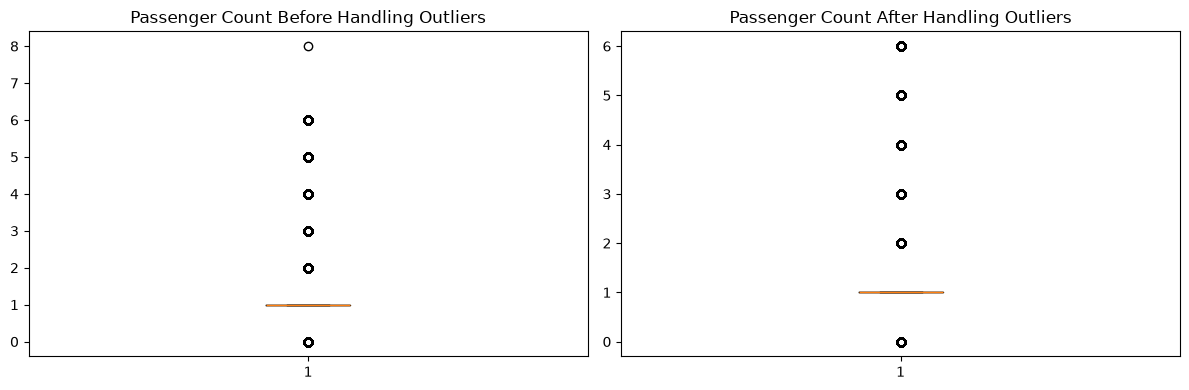

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].boxplot(df['passenger_count'])
axes[0].set_title('Passenger Count Before Handling Outliers')

# Remove 8+ passengers (NYC taxi legal max is 6-7)
df = df[~(df['passenger_count'] > 7)]

axes[1].boxplot(df['passenger_count'])
axes[1].set_title('Passenger Count After Handling Outliers')
plt.tight_layout()
plt.show()

In [45]:
print("MTA Tax values before handling outliers:")
print(df['mta_tax'].value_counts().sort_index())

# Valid zero-tax categories per TLC rules
non_metered_payments = [3, 4, 5, 6]  # No charge, Dispute, Unknown, Voided
non_metered_ratecodes = [5, 6]        # Negotiated fare, Group ride

zero_tax = df['mta_tax'] == 0
valid_zero = (
    df['payment_type'].isin(non_metered_payments) |
    df['RatecodeID'].isin(non_metered_ratecodes)
)

# Fix invalid zeros → should be $0.50
df.loc[zero_tax & ~valid_zero, 'mta_tax'] = 0.5

# Fix any other non-standard values → $0.50
df.loc[(df['mta_tax'] != 0) & (df['mta_tax'] != 0.50), 'mta_tax'] = 0.5

print("\nMTA Tax values after handling outliers:")
print(df['mta_tax'].value_counts().sort_index())

MTA Tax values before handling outliers:
mta_tax
0.00      2700
0.05         3
0.30         1
0.50    286933
0.80        14
Name: count, dtype: int64

MTA Tax values after handling outliers:
mta_tax
0.0      1479
0.5    288172
Name: count, dtype: int64


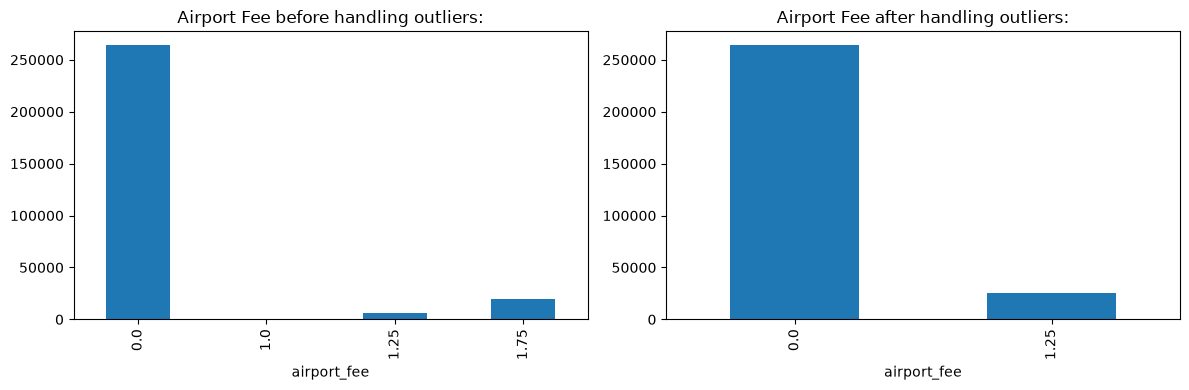

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df['airport_fee'].value_counts().sort_index().plot(kind='bar', ax=axes[0])
axes[0].set_title('Airport Fee before handling outliers:')

# Enforce TLC rule: $1.25 for airport pickups, $0 for all others
airport_zones = [132, 138]
df.loc[df['PULocationID'].isin(airport_zones), 'airport_fee'] = 1.25
df.loc[~df['PULocationID'].isin(airport_zones), 'airport_fee'] = 0.0

df['airport_fee'].value_counts().sort_index().plot(kind='bar', ax=axes[1])
axes[1].set_title('Airport Fee after handling outliers:')
plt.tight_layout()
plt.show()

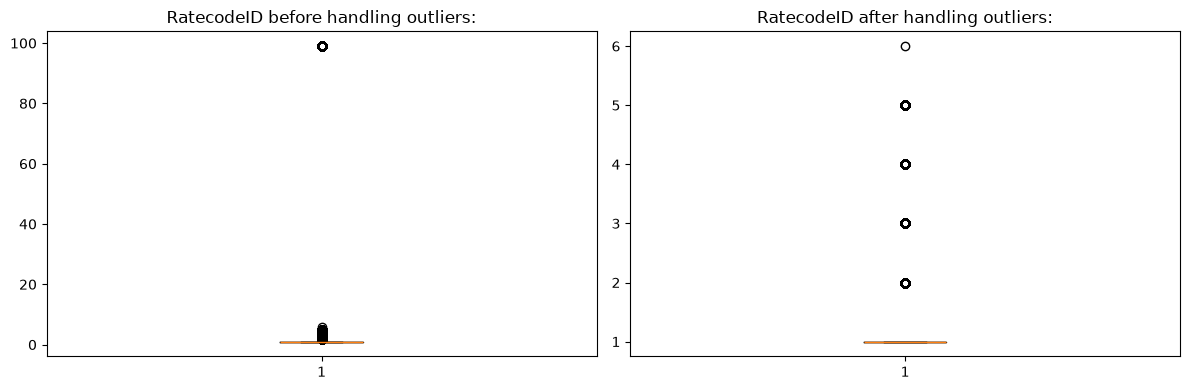

In [47]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].boxplot(df['RatecodeID'])
axes[0].set_title('RatecodeID before handling outliers:')

# Valid codes are 1-6 only per data dictionary
df = df[~(df['RatecodeID'] > 6)]

axes[1].boxplot(df['RatecodeID'])
axes[1].set_title('RatecodeID after handling outliers:')
plt.tight_layout()
plt.show()

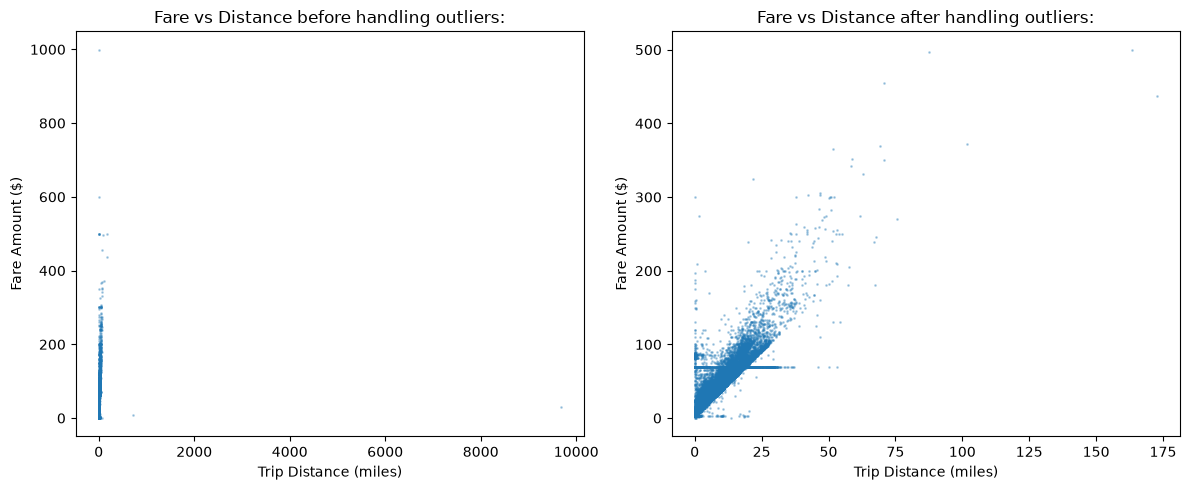

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(df['trip_distance'], df['fare_amount'], alpha=0.3, s=1)
axes[0].set_title('Fare vs Distance before handling outliers:')
axes[0].set_xlabel('Trip Distance (miles)')
axes[0].set_ylabel('Fare Amount ($)')

df = df[~(
    # Near-zero distance but fare > 300 
    ((df['trip_distance'] < 1) & (df['fare_amount'] > 300)) |

    # Both distance and fare are 0 but zones are different 
    ((df['trip_distance'] == 0) & (df['fare_amount'] == 0) &
     (df['PULocationID'] != df['DOLocationID'])) |

    # Over 250 miles — physically impossible for NYC taxi
    (df['trip_distance'] > 250) |

    # payment_type 0 does not exist in the data dictionary
    (df['payment_type'] == 0)
)]

# Remove non-positive fares
df = df[df['fare_amount'] > 0]

# Remove all zero-distance trips 
df = df[df['trip_distance'] > 0]

axes[1].scatter(df['trip_distance'], df['fare_amount'], alpha=0.3, s=1)
axes[1].set_title('Fare vs Distance after handling outliers:')
axes[1].set_xlabel('Trip Distance (miles)')
axes[1].set_ylabel('Fare Amount ($)')
plt.tight_layout()
plt.show()

In [49]:
print(f"Final shape:{df.shape}")

# Save
df.reset_index(drop=True, inplace=True)
df.to_parquet('../data/processed/nyc_taxi_clean.parquet', index=False)
print("Saved")

Final shape:(284600, 21)
Saved
